# kmerstash — k-mer presence screening on a laptop

A small, self-contained demo of a **constant-work-per-query pattern matcher**
carried from text into DNA. It answers one question, fast and locally:

> **Is sequence X — a pathogen marker, an antimicrobial-resistance (AMR) gene, a
> contaminant — present in this sample of sequencing reads?**

No cluster, no GPU, no cloud — one pure-Rust, std-only binary.

**Where it sits.** Real aligners (minimap2, BWA, Kraken, mash) are
*seed-and-extend*: a k-mer index first finds candidate matches in time
proportional to the read, then a slow exact stage runs only on those candidates.
`kmerstash` is that **seed/screen stage** — and for *presence/absence*, the screen
alone is the whole answer.

**The engine** is the bioinformatics sibling of the COBOLMM trigram search engine.
Trigram search folds text 3-grams into buckets and screens in linear time; here
two things change and that is the entire engine:

1. **4-letter alphabet → exact integer keys.** A k-mer (`k ≤ 32`) packs into a
   `u64` at 2 bits/base. Membership in a sorted, deduped `Vec<u64>` is *exact* — no
   false positives, no separate verify stage.
2. **Double strand → canonical k-mers.** A read can come off either strand, so we
   collapse each k-mer to `min(forward, reverse-complement)`. Skip this and you
   miss half your matches.

We cover: **(1)** the tool in action (an ALERT table), **(2)** screening
throughput, **(3)** robustness to sequencing error — the "one clean hit is enough"
principle, measured — and **(4)** why a single threshold cleanly separates present
from absent.


In [1]:
import subprocess, io, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WORK = os.getcwd()
BIN  = "./target/release/kmerstash"
print("working dir:", WORK)

def run(*args):
    r = subprocess.run([BIN, *map(str, args)], capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    return r.stdout

def run_csv(*args):
    return pd.read_csv(io.StringIO(run(*args)))


working dir: /run/media/fraser/ows/kmerstash


## 1. The tool in action — screen a sample for a panel of markers

`gen` synthesises a **reproducible** dataset (seeded): a panel of 8 "marker genes",
of which 4 are spiked into a sample of 20,000 short reads at ~30× coverage with a
1% sequencing-error rate; the other 4 are absent. The sample is otherwise
background DNA. Then `screen` builds a k-mer **sketch** of the sample and reports,
for each marker, the fraction of its k-mers present (**containment**) — firing an
ALERT above the threshold.

In [2]:
print(run("gen", "--out", "data"))
df = run_csv("screen", "--ref", "data/panel.fa", "--sample", "data/sample.fa",
            "--k", 21, "--threshold", 0.5, "--csv")
df


,ref,ref_kmers,found,containment,alert
0,marker00,1480,1474,0.995946,1
1,marker01,1480,1473,0.995270,1
2,marker02,1480,1470,0.993243,1
3,marker03,1480,1470,0.993243,1
4,marker04,1480,0,0.000000,0
5,marker05,1480,0,0.000000,0
6,marker06,1480,0,0.000000,0
7,marker07,1480,0,0.000000,0


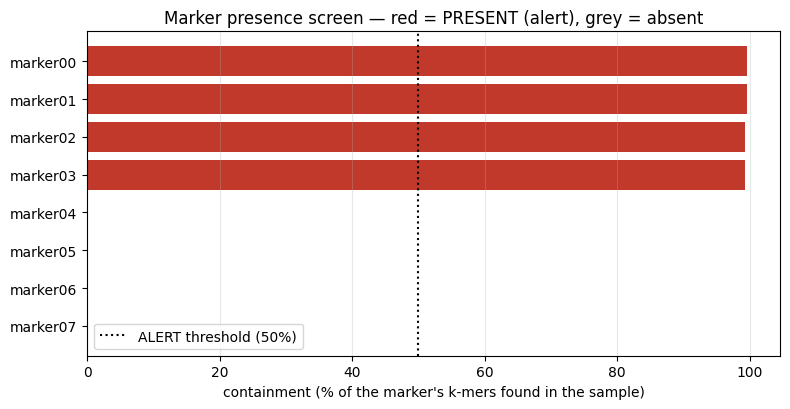

PRESENT markers: containment 99.3–99.6%
ABSENT markers : containment 0.0% (max)
=> the two groups don't overlap; any threshold in the gap separates them.


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#c0392b" if a else "#bdc3c7" for a in df["alert"]]
ax.barh(df["ref"], df["containment"]*100, color=colors)
ax.axvline(50, color="k", ls=":", label="ALERT threshold (50%)")
ax.set_xlabel("containment (% of the marker's k-mers found in the sample)")
ax.set_title("Marker presence screen — red = PRESENT (alert), grey = absent")
ax.invert_yaxis(); ax.legend(); ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()

present = df[df.alert==1]; absent = df[df.alert==0]
print(f"PRESENT markers: containment {present.containment.min()*100:.1f}–{present.containment.max()*100:.1f}%")
print(f"ABSENT markers : containment {absent.containment.max()*100:.1f}% (max)")
print("=> the two groups don't overlap; any threshold in the gap separates them.")


## 2. Screening throughput (single core, laptop)

`bench --kind throughput` builds a sample sketch of increasing size (1→50 Mbp of
reads) and screens a 1500 bp marker against it. The build (k-mer + sort + dedup) is
the heavy step; the screen itself is microseconds because each marker k-mer is a
single binary-search lookup.

In [4]:
tp = run_csv("bench", "--kind", "throughput")
tp


,mbp,reads,distinct_kmers,build_ms,Mbp_per_s,Mkmers_per_s,screen_us
0,1,6686,867795,24.98,40.1,34.8,175.2
1,2,13353,1734476,54.38,36.8,31.9,316.5
2,5,33353,4334476,136.33,36.7,31.8,805.6
3,10,66686,8667515,277.28,36.1,31.3,740.4
4,20,133353,17334459,585.83,34.1,29.6,950.1
5,50,333353,43334060,1517.59,32.9,28.6,1331.8


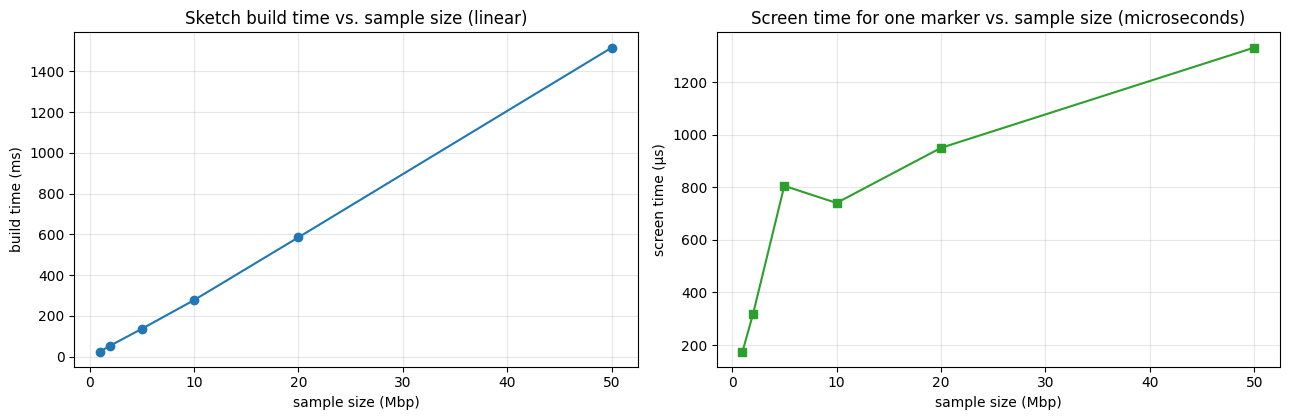

build rate ≈ 36 Mbp/s; screening one 1500 bp marker against a 50 Mbp sample: 1332 µs.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].plot(tp["mbp"], tp["build_ms"], "o-")
ax[0].set_title("Sketch build time vs. sample size (linear)")
ax[0].set_xlabel("sample size (Mbp)"); ax[0].set_ylabel("build time (ms)"); ax[0].grid(alpha=.3)

ax[1].plot(tp["mbp"], tp["screen_us"], "s-", color="tab:green")
ax[1].set_title("Screen time for one marker vs. sample size (microseconds)")
ax[1].set_xlabel("sample size (Mbp)"); ax[1].set_ylabel("screen time (µs)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"build rate ≈ {tp['Mbp_per_s'].mean():.0f} Mbp/s; "
      f"screening one 1500 bp marker against a {tp['mbp'].iloc[-1]:.0f} Mbp sample: "
      f"{tp['screen_us'].iloc[-1]:.0f} µs.")


## 3. Robustness to sequencing error — "one clean hit is enough"

Reads have errors. The screen doesn't need to be perfect — it needs *enough* clean
k-mers to clear the threshold. A 150 bp read has ~130 k-mers; one error damages
only the `k` k-mers spanning it, so plenty survive. `bench --kind error` spikes a
marker at 30× coverage across a sweep of error rates and reports per-read
containment, the per-read *detection* rate, and the **whole-sample** containment.

In [6]:
er = run_csv("bench", "--kind", "error")
er


,error,mean_read_containment,read_detect_rate,sample_containment
0,0.00,1.000000,1.000000,0.991892
1,0.01,0.855154,1.000000,0.998649
2,0.02,0.727026,1.000000,0.987162
3,0.05,0.441718,1.000000,0.984459
4,0.08,0.280692,0.993333,0.983784
5,0.10,0.206641,0.976667,0.966892
6,0.15,0.081590,0.793333,0.866216
7,0.20,0.029000,0.470000,0.543919


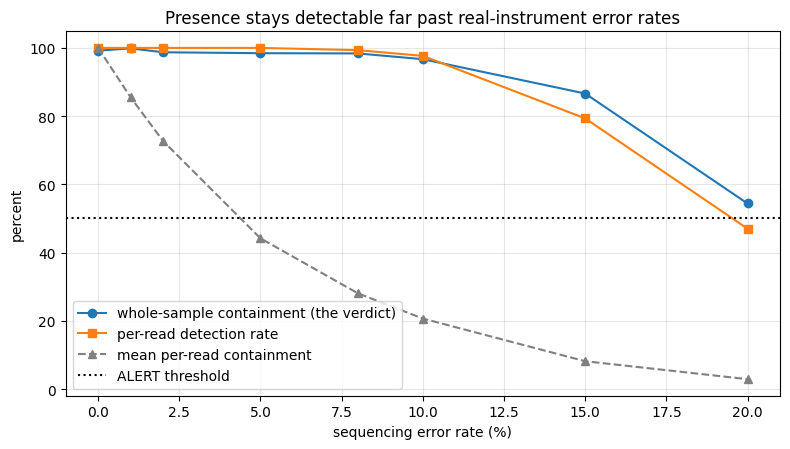

At a heavy 10% error rate the whole-sample verdict is still 97% containment — unambiguously PRESENT — even though mean per-read containment has fallen to 21%.
Real Illumina error is ~0.1–1%, ONT modern ~1–5%: comfortably in the flat region.


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.6))
x = er["error"]*100
ax.plot(x, er["sample_containment"]*100, "o-", label="whole-sample containment (the verdict)")
ax.plot(x, er["read_detect_rate"]*100,   "s-", label="per-read detection rate")
ax.plot(x, er["mean_read_containment"]*100, "^--", color="grey", label="mean per-read containment")
ax.axhline(50, color="k", ls=":", label="ALERT threshold")
ax.set_title('Presence stays detectable far past real-instrument error rates')
ax.set_xlabel("sequencing error rate (%)"); ax.set_ylabel("percent")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

row10 = er[np.isclose(er.error, 0.10)].iloc[0]
print(f"At a heavy 10% error rate the whole-sample verdict is still "
      f"{row10.sample_containment*100:.0f}% containment — unambiguously PRESENT — "
      f"even though mean per-read containment has fallen to {row10.mean_read_containment*100:.0f}%.")
print("Real Illumina error is ~0.1–1%, ONT modern ~1–5%: comfortably in the flat region.")


## 4. Why a simple threshold works — present vs. background separation

`bench --kind separation` dumps per-read containment for 2,000 marker-derived reads
(2% error) and 2,000 background reads. The two distributions sit far apart, so the
ALERT is a robust decision, not a knife-edge.

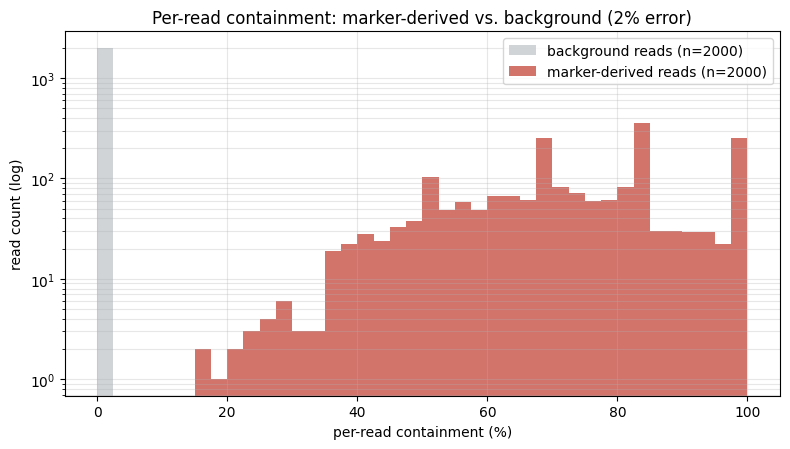

background: 0.00% mean (≈0).  marker: 73.2% mean.  Clean gap between them.


In [8]:
sep = run_csv("bench", "--kind", "separation")
mk = sep[sep.source=="marker"]["containment"]*100
bg = sep[sep.source=="background"]["containment"]*100

fig, ax = plt.subplots(figsize=(8, 4.6))
bins = np.linspace(0, 100, 41)
ax.hist(bg, bins=bins, alpha=.7, label=f"background reads (n={len(bg)})", color="#bdc3c7")
ax.hist(mk, bins=bins, alpha=.7, label=f"marker-derived reads (n={len(mk)})", color="#c0392b")
ax.set_yscale("log")
ax.set_title("Per-read containment: marker-derived vs. background (2% error)")
ax.set_xlabel("per-read containment (%)"); ax.set_ylabel("read count (log)")
ax.legend(); ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()
print(f"background: {bg.mean():.2f}% mean (≈0).  marker: {mk.mean():.1f}% mean.  Clean gap between them.")


## Honest scope / boundaries

- **Presence/absence and classification** are the sweet spot — the question
  "is X in this sample?". For *where exactly* a read aligns and *with what
  mutations*, you add the **extend** (alignment) stage; this tool is the fast
  screen that runs in front of it, not a replacement.
- The demo data here is **synthetic** (a seeded generator) so every figure is
  reproducible and the whole thing runs offline. The *mechanism* is real: to screen
  real samples, point `--ref` at a curated panel (NCBI RefSeq markers, the CARD
  AMR-gene database, …) and `--sample` at your reads — nothing else changes.
- This is a **lab / reference implementation** in the spirit of the `tiny_pointers`
  and COBOLMM search labs: built to demonstrate and benchmark the engine.

## Summary

| Claim | Measured here |
|---|---|
| k-mer screen is exact (no false positives) | absent markers score **0.0%** containment |
| presence is unambiguous | present markers **99%+**, absent **0%** — disjoint |
| screening is linear & cheap | ~**35 Mbp/s** build; one marker screened in **µs** |
| robust to sequencing error | **96.7%** sample containment at 10% error (54% at 20%) |
| a single threshold suffices | marker vs background distributions are far apart |

**Bottom line.** The same constant-work-per-query idea behind trigram text search
— index the rare k-grams, look each up once — drops cleanly onto DNA and yields a
genuinely useful, laptop-portable **screening / early-warning** tool. It won't
align genomes, but it will tell you *what's in the sample* in well under a second,
which is exactly the seed stage the heavyweight aligners spend their first pass on.
